#### Geopandas Homework - Anna Horton
Below is my analysis of the relationship between green space, Mardi Gras parade routes, and the wards of New Orleans, Louisiana. I want to understand if there is a relationship between the amount of green space in a ward and the prevalence of the parade route in that area. I will eventually also involve the demographics of the wards to identify if this is a trend that could be attributed to the demographic makeup of the neighborhoods. I specifically want to look at the biggest ward and the smallest ward and understand the differences between them. 

##### First step: upload and filter the data for just the attributes that I need

In [2]:
## uploading the packages
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## uploading the data itself
routes = gpd.read_file("Mardi_Gras_Routes_20261003.geojson")
greenspace = gpd.read_file("Open_Greenspace_20261003.geojson")
wards = gpd.read_file("Wards_20261003.geojson")

## making sure all of the projections are the same - getting some weird results further down
routes = routes.to_crs(epsg = 32615)
greenspace = greenspace.to_crs(epsg = 32615)
wards = wards.to_crs(epsg = 32615)

In [ ]:
routes
routes = routes[["parade", "location", "geometry"]]

## creating a mask to filter out NaN values
mask = routes[("parade") == "NaN"]
routes[mask]

KeyError: False

In [4]:
greenspace
greenspace = greenspace[["name", "geometry"]]

In [5]:
wards
wards = wards[["ward", "shape_area", "geometry"]]

##### Second step: make an analysis plan
I want to get at the relationship between the wards, the greenspace, and the Mardi Gras parade routes. 
I would first need to plot the ward boundaries, along with the parade routes and the greenspaces so that I can create a visual representation of the area. Then, I will find out which parade routes intersect with the boundaries of the wards and which are completely within. Third, I will complete an analysis to find out which greenspaces are within the wards themselves and rank the wards by amount of greenspace and create a new layer with their intersections. Fourth, I will create a layer that represents the relationship between the wards with greenspace and the routes to identify which wards have the most or any parade routes that wind through them. At the conclusion of that analysis, I will be able to get at the answer to my hypothesis. 

<Axes: >

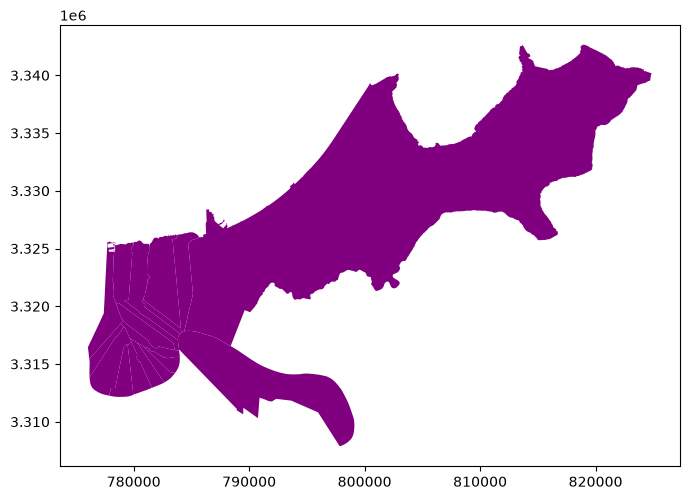

In [6]:
## plotting each of the earlier layers so that I can understand exactly where I am looking at
### plotting the ward boundaries
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")


<Axes: >

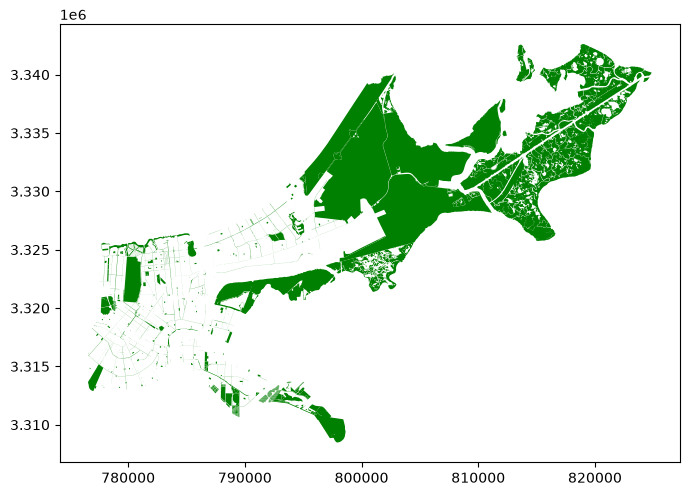

In [7]:
### plotting the greenspace boundaries
fig, ax = plt.subplots(figsize=(8,7))
greenspace.plot(ax=ax, color="green")

<Axes: >

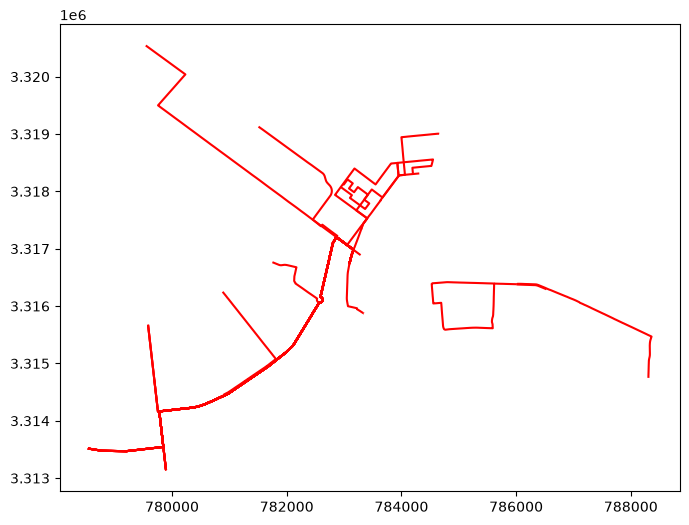

In [8]:
### plotting the parade routes
fig, ax = plt.subplots(figsize=(8,7))
routes.plot(ax=ax, color="red")


<Axes: >

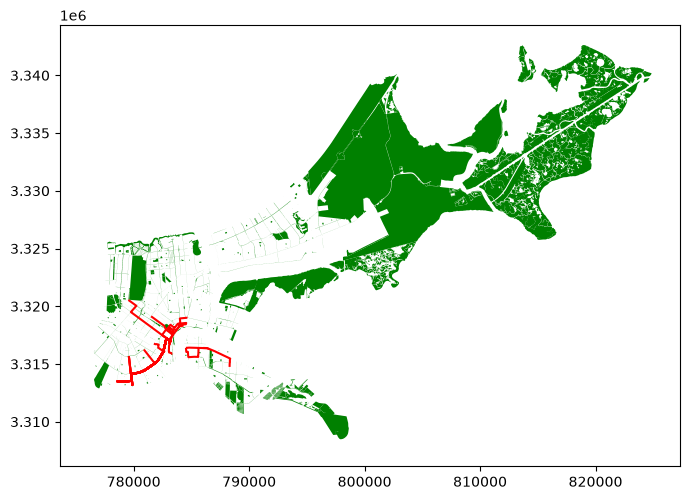

In [9]:
## plotting them all on top of each other to see if my analysis is doing anything helpful
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="white")
greenspace.plot(ax=ax, color="green")
routes.plot(ax=ax, color="red")

## visualized: there is some overlap of the parade routes and the ward boundaries, as well as some minimal overlap with the greenspace

#### Analysis!

In [10]:
## sorting the wards by the largest
wards = wards.sort_values("shape_area", ascending = True)
wards

# selecting out the biggest ward and the smallest ward to compare
big_ward = wards.iloc[0]
big_ward

ward                                                         14
shape_area                                   100139851.59973092
geometry      MULTIPOLYGON (((779520.5487918365 3317533.7189...
Name: 10, dtype: object

In [11]:
## after asking AI, this is in fact the check that I should have been doing all along - the analysis that was being completed was in fact correct
print(routes.geometry.intersects(wards.union_all()).sum(), "routes hit any ward")
print(routes.geometry.intersects(big_ward.geometry).sum(), "routes hit big_ward")

36 routes hit any ward
0 routes hit big_ward


In [ ]:
### finding out which parade routes intersect with the biggest ward boundaries
routes_inside_big = routes.geometry.intersects(big_ward.geometry)
routes_inside_big

## there are no routes that intersect the biggest ward, which means that I don't need to do any further analysis

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
dtype: bool

In [13]:
## finding out if any parade routes intersect the smallest ward (based on the information that I have now, I think that the answer is going to be yes)
small_ward = wards.iloc[-1]

## applying the intersection logic
routes_inside1 = routes.geometry.intersects(small_ward.geometry)
routes_inside1

# there are a good amount of routes that intersect the small ward's geometry

0      True
1      True
2      True
3      True
4      True
5      True
6     False
7      True
8      True
9      True
10     True
11    False
12     True
13     True
14    False
15     True
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23    False
24     True
25     True
26     True
27     True
28     True
29    False
30     True
31     True
32     True
33     True
34     True
35     True
dtype: bool

In [ ]:
## are there any routes that are completely within the smaller ward?
routes_inside2 = routes.geometry.within(small_ward.geometry)
print(routes_inside2)

## there are no routes that are completely within the boundaries of the smaller ward, they all just intersect

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
dtype: bool


In [19]:
## now, instead of doing the analysis based on the biggest ward and the smallest ward, I'm going to use a spatial join and apply the logic to each element within each distinct dataset
## instead, I'll make a spatial join that applies the intersection logic to understand if there are routes that intersect with the boundaries of each of the wards
## considering that there is a relationship (clearly) between the smallest ward and the parade routes given the amount of intersections, but the routes have to be intersecting with some other wards
routes_int = gpd.sjoin(wards, routes, how = "left", predicate = "intersects")
routes_int

,ward,shape_area,geometry,index_right,parade,location
10,14,100139851.59973092,"MULTIPOLYGON (((779520.549 3317533.719, 779644...",NaN,NaN,NaN
14,17,101064187.50326879,"MULTIPOLYGON (((777994.198 3325560.694, 777998...",NaN,NaN,NaN
11,8,105797659.11738931,"MULTIPOLYGON (((785671.153 3325966.081, 785676...",0.0,Krewe Du Vieux,Downtown
11,8,105797659.11738931,"MULTIPOLYGON (((785671.153 3325966.081, 785676...",2.0,Bohème,Downtown
11,8,105797659.11738931,"MULTIPOLYGON (((785671.153 3325966.081, 785676...",11.0,Chewbacchus,Downtown
...,...,...,...,...,...,...
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",13.0,Druids,Uptown
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",22.0,Hermes,Uptown
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",10.0,Rex,Uptown
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",4.0,Iris,Uptown


In [17]:
## now I'm going to make a spatial join with the greenspaces and the wards to see how much overlap there is there
green_within = gpd.sjoin(greenspace, wards, how = "left", predicate = "within")
# green_within['ward'].value_counts()
green_within

# there are instances in which greenspaces are contained within the boundaries of wards
## there are so many rows because within maes a new row for every small greenspace element that is within a ward, and there are usually multiple greenspaces within a ward

,name,geometry,index_right,ward,shape_area
0,NaN,"MULTIPOLYGON (((791887.413 3312326.742, 791856...",6.0,15,578581641.529585
1,NaN,"MULTIPOLYGON (((791545.07 3326802.158, 791548....",13.0,9,4157223623.3250475
2,NaN,"MULTIPOLYGON (((789344.756 3321114.137, 789341...",13.0,9,4157223623.3250475
3,NaN,"MULTIPOLYGON (((788512.463 3311631.418, 788512...",6.0,15,578581641.529585
4,NaN,"MULTIPOLYGON (((788022.011 3318327.924, 788022...",13.0,9,4157223623.3250475
...,...,...,...,...,...
5536,NaN,"MULTIPOLYGON (((789103.348 3321284.923, 789100...",13.0,9,4157223623.3250475
5537,NaN,"MULTIPOLYGON (((785631.372 3316622.977, 785632...",6.0,15,578581641.529585
5538,West End Park,"MULTIPOLYGON (((777808.319 3324915.78, 777805....",14.0,17,101064187.50326879
5539,NaN,"MULTIPOLYGON (((789615.791 3321207.841, 789612...",13.0,9,4157223623.3250475


In [18]:
## rank the wards by the amt of greenspace
## creating a counts column that will actually work
sorted = green_within.sort_values(["ward"])
sorted

,name,geometry,index_right,ward,shape_area
1520,Camp Street Finger Park,"MULTIPOLYGON (((782463.205 3315148.876, 782463...",8.0,1,23545965.274778757
1023,NaN,"MULTIPOLYGON (((783530.86 3315219.034, 783519....",8.0,1,23545965.274778757
2315,NaN,"MULTIPOLYGON (((781653.94 3315907.728, 781660....",8.0,1,23545965.274778757
2314,NaN,"MULTIPOLYGON (((782944.525 3315487.053, 782927...",8.0,1,23545965.274778757
4852,NaN,"MULTIPOLYGON (((783629.098 3315502.76, 783629....",8.0,1,23545965.274778757
...,...,...,...,...,...
5473,NaN,"MULTIPOLYGON (((781672.756 3318105.985, 781746...",NaN,NaN,NaN
5479,NaN,"MULTIPOLYGON (((779844.998 3313535.356, 779848...",NaN,NaN,NaN
5484,NaN,"MULTIPOLYGON (((778646.335 3320260.748, 778634...",NaN,NaN,NaN
5509,NaN,"MULTIPOLYGON (((780529.66 3315244.081, 780530....",NaN,NaN,NaN
